In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

In [40]:
#aqui limpimaos los datos!!
df_original = pd.read_stata('Mexico-2023-full-data.dta')

cols = {'d2': 'sales', 'l1': 'employees', 'b5': 'start_year', 
        'l10': 'training', 'k82': 'financing', 'd3c': 'export_share'}

df_clean = df_original[list(cols.keys())].copy()
df_clean.rename(columns=cols, inplace=True)

# aqui limpiamos los valores nulos
for col in ['sales', 'employees', 'start_year', 'export_share']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

In [41]:
# hacemos las categorias 1 y 0 
df_clean['training'] = df_clean['training'].map({
    'Yes': 1,
    'No': 0
})
df_clean['financing'] = df_clean['financing'].map({
    'Yes, both a line of credit and a loan': 1,
    'Yes, a loan only': 1,
    'Yes, a line of credit only': 1,
    'No': 0
})
#hacemos "successful"
promedio = df_clean['sales'].mean()
df_clean['successful'] = (df_clean['sales'] > promedio).astype(int)
df_log = df_clean.dropna().copy()


In [42]:
# variables dependientes e independientes
X = df_log[['employees', 'training', 'financing']]
y = df_log['successful']

# Dividir entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

#modelo base 
ns_probs = np.zeros(len(y_test))

#regresion logistica 
model = LogisticRegression(max_iter=1000)
model.fit(X_train_s, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [46]:
#predecimos las probabilidades
lr_probs = model.predict_proba(X_test_s)[:, 1]

In [47]:
ns_auc = roc_auc_score(y_test, ns_probs)
lr_auc = roc_auc_score(y_test, lr_probs)

print(f'Sin entrenar: ROC AUC = {ns_auc:.3f}')
print(f'Regresión Logística: ROC AUC = {lr_auc:.3f}')

Sin entrenar: ROC AUC = 0.500
Regresión Logística: ROC AUC = 0.975


In [49]:
#Calculamos ROC
ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)

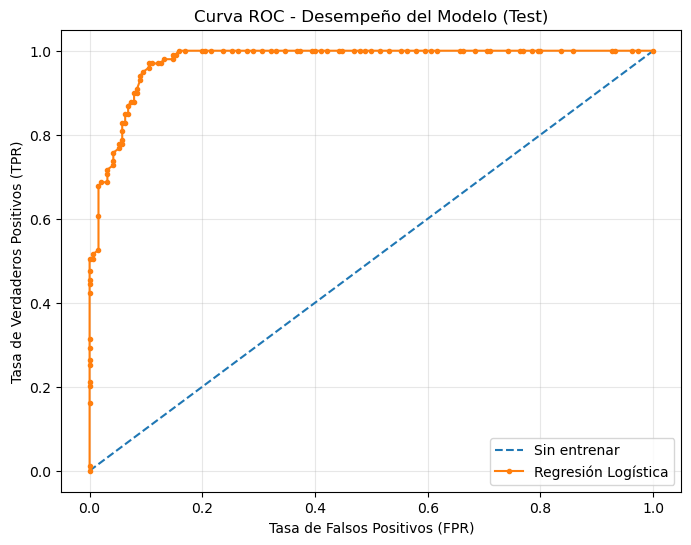

In [50]:
# graficamos
plt.figure(figsize=(8,6))
plt.plot(ns_fpr, ns_tpr, linestyle='--', label='Sin entrenar')
plt.plot(lr_fpr, lr_tpr, marker='.', label='Regresión Logística')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Desempeño del Modelo (Test)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Conclusiones ##

**¿Se puede clasificar si una empresa es "exitosa" según sus carac.?**

Si, es posible clasificar si una empresa es “exitosa” a partir de sus características. El modelo sin entrenar obtuvo un AUC de 0.500, lo que indica una clasificación al azar. En cambio, la regresión logística alcanzó un AUC de 0.975, lo que demuestra una alta capacidad de discriminación entre empresas exitosas y no exitosas. Esto significa que variables como número de empleados, capacitación y financiamiento contienen información suficiente para predecir el desempeño empresarial con un alto nivel de precisión.

## CONCLUSIÓN FINAL EN EL ACHIVO "CONCLUSION.md" ##